In [1]:
# welcome to part 3. exploring SDKs
# demo 1 - 3.1 - checking installations
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.h(0)

print(qc)

   ┌───┐
q: ┤ H ├
   └───┘


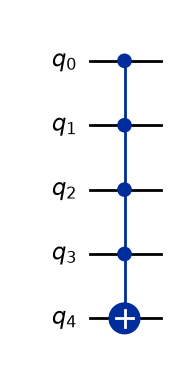

In [3]:
# part 3.2
# demo 1 - append() method
from qiskit import QuantumCircuit
from qiskit.circuit.library import MCXGate

qc = QuantumCircuit(5)

# A multi-controlled X gate with 4 control qubits and 1 target qubit.
mcx = MCXGate(4)

# Controls: qubits 0, 1, 2, 3. Target: qubit 4.
qc.append(mcx, [0, 1, 2, 3, 4])

qc.draw("mpl")

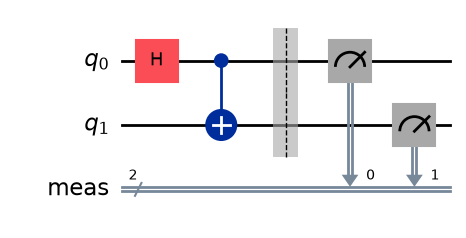

In [7]:
# demo 2 - 3.2 - compose() method
from qiskit import QuantumCircuit

subcircuit = QuantumCircuit(2, name="bell_prep")
subcircuit.h(0)
subcircuit.cx(0, 1)

qc = QuantumCircuit(2)
qc.compose(subcircuit, qubits=[0, 1], inplace=True)
qc.measure_all()

qc.draw("mpl")

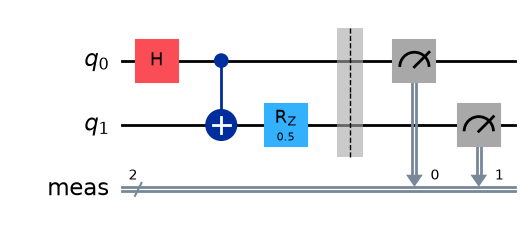

In [8]:
# demo 3 - 3.2 - gate alternatives, object based
from qiskit import QuantumCircuit
from qiskit.circuit.library import HGate, CXGate, RZGate

qc = QuantumCircuit(2)

qc.append(HGate(), [0])
qc.append(CXGate(), [0, 1])
qc.append(RZGate(0.5), [1])
qc.measure_all()

qc.draw("mpl")

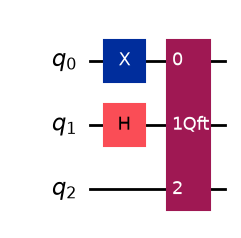

In [9]:
# demo 4 - 3.2 - quantum fourier transform
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate

qc = QuantumCircuit(3)

# Prepare a simple input state.
qc.x(0)
qc.h(1)

# Apply the QFT on all three qubits.
qc.append(QFTGate(3), [0, 1, 2])

qc.draw("mpl")

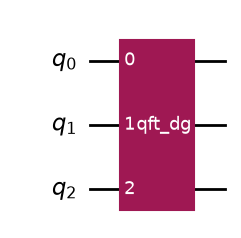

In [10]:
# demo 5 - 3.2 - QFT inverse
iqft = QFTGate(3).inverse()

qc = QuantumCircuit(3)
qc.append(iqft, [0, 1, 2])
qc.draw("mpl")
# QFTGate is preferred to using QFT for future projects

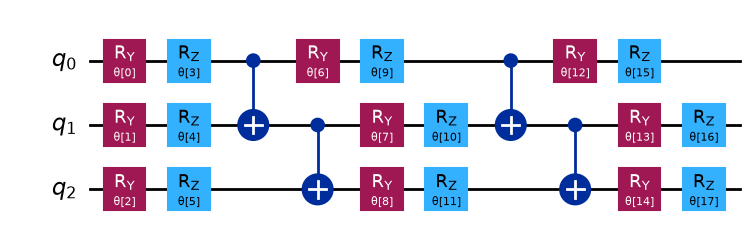

In [11]:
# demo 6 - 3.2 - Ansatz circuit
from qiskit.circuit.library import efficient_su2

ansatz = efficient_su2(
    num_qubits=3,
    su2_gates=["ry", "rz"],
    entanglement="linear",
    reps=2
)

ansatz.draw("mpl")

Number of parameters: 18
ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17])])


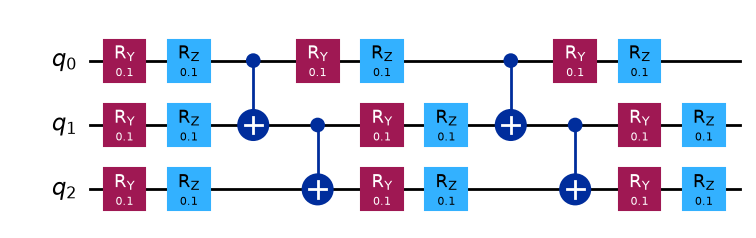

In [12]:
# demo 7 - 3.2 - parameter edit for ansatz
print("Number of parameters:", ansatz.num_parameters)
print(ansatz.parameters)

values = [0.1] * ansatz.num_parameters
bound_ansatz = ansatz.assign_parameters(values)

bound_ansatz.draw("mpl")

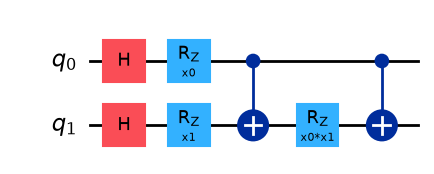

In [13]:
# demo 8 - 3.2 - feature map
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

x0 = Parameter("x0")
x1 = Parameter("x1")

feature_map = QuantumCircuit(2, name="feature_map")
feature_map.h([0, 1])
feature_map.rz(x0, 0)
feature_map.rz(x1, 1)
feature_map.cx(0, 1)
feature_map.rz(x0 * x1, 1)
feature_map.cx(0, 1)

feature_map.draw("mpl")

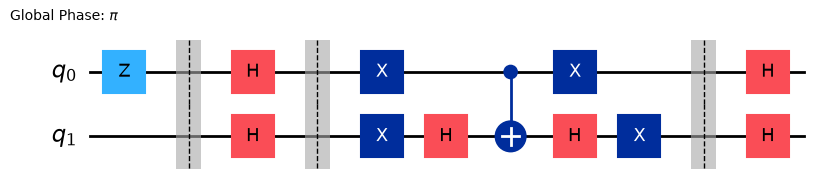

In [14]:
# demo 9 - 3.2 - grover operator
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator

# Mark states where qubit 0 is |1> by applying a phase flip.
oracle = QuantumCircuit(2, name="oracle")
oracle.z(0)

# Build the Grover operator from the oracle.
grover_op = grover_operator(
    oracle,
    insert_barriers=True
)

grover_op.draw("mpl")

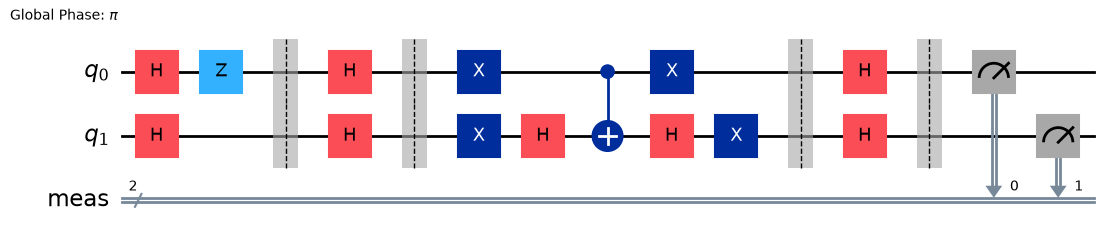

In [15]:
# demo 10 - 3.2 - search circuit with grover?
search = QuantumCircuit(2)

# Prepare uniform superposition.
search.h([0, 1])

# Apply one Grover iteration.
search.compose(grover_op, inplace=True)

search.measure_all()
search.draw("mpl")

{'10': 260, '11': 264, '01': 252, '00': 248}


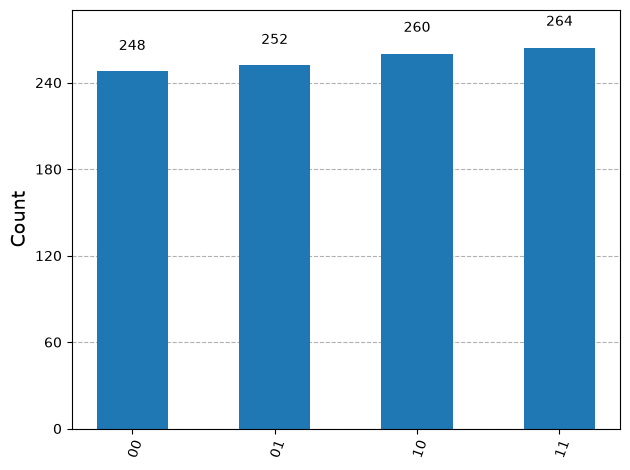

In [18]:
# demo 11 - 3.2 - simulate the grover style circuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()
job = simulator.run(search, shots=1024)
result = job.result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)

Original operations: OrderedDict({'h': 8, 'barrier': 4, 'x': 4, 'measure': 2, 'z': 1, 'cx': 1})
ISA operations: OrderedDict({'rz': 12, 'sx': 6, 'barrier': 4, 'x': 4, 'measure': 2, 'cz': 1})
Number of parameters: 0
Number of parameters: 0


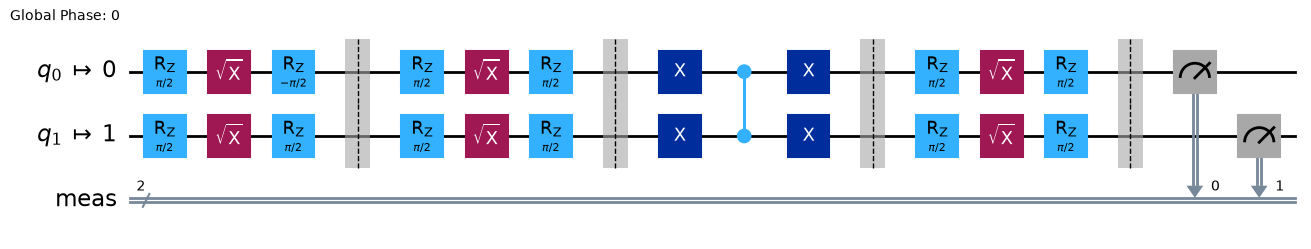

In [24]:
# demo 12 - 3.2 - transpilation demo
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.least_busy(
    simulator=False,
    operational=True,
    min_num_qubits=search.num_qubits
)

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_search = pm.run(search)

print("Original operations:", search.count_ops())
print("ISA operations:", isa_search.count_ops())

isa_search.draw("mpl", idle_wires=False)

In [22]:
# demo 13 - 3.2 - sampler demo
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
job = sampler.run([isa_search], shots=1024)

print("Job ID:", job.job_id())

Job ID: d99b9fotcv6s73dn3kbg


{'00': 273, '01': 256, '10': 259, '11': 236}


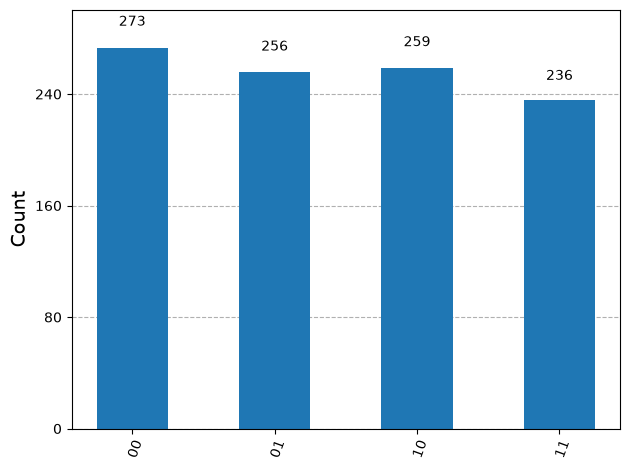

In [23]:
# continued
result = job.result()
pub_result = result[0]
counts = pub_result.data.meas.get_counts()

print(counts)
plot_histogram(counts)